# DeepGaze IIE — Nhập tay & Visualize kết quả thực nghiệm

**Quy trình:**
1. **Cell 1** — Setup (import, định nghĩa hàm)
2. **Cell 2 → 11** — Nhập dữ liệu từng tổ hợp (C(4,2)=6 + C(4,3)=4)
3. **Cell 12** — Bảng so sánh tổng hợp
4. **Cell 13** — Training curves từng tổ hợp
5. **Cell 14** — Biểu đồ bar chart so sánh best IG và NSS

**Cách nhập:** Mỗi cell nhập 1 tổ hợp, điền số liệu từ output Colab đã chạy.
Tổ hợp chưa chạy → để list rỗng `[]`.

---
## Cell 1 — Setup

In [1]:
# ============================================================
# CELL 1: SETUP — chay 1 lan dau tien
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pandas as pd
from IPython.display import display
import warnings
warnings.filterwarnings('ignore')

# Kho luu tru du lieu tat ca experiments
ALL_DATA = {}

BACKBONE_NAMES = ['ShapeNetC','EfficientNetB5','DenseNet201','ResNext50']

ALL_EXPERIMENTS_INFO = {
    # Chap 2
    'SN_EN'    : {'indices':[0,1], 'group':2},
    'SN_DN'    : {'indices':[0,2], 'group':2},
    'SN_RX'    : {'indices':[0,3], 'group':2},
    'EN_DN'    : {'indices':[1,2], 'group':2},
    'EN_RX'    : {'indices':[1,3], 'group':2},
    'DN_RX'    : {'indices':[2,3], 'group':2},
    # Chap 3
    'SN_EN_DN' : {'indices':[0,1,2], 'group':3},
    'SN_EN_RX' : {'indices':[0,1,3], 'group':3},
    'SN_DN_RX' : {'indices':[0,2,3], 'group':3},
    'EN_DN_RX' : {'indices':[1,2,3], 'group':3},
}

def register(exp_name, sal_data, mit_data):
    """Luu du lieu 1 experiment vao ALL_DATA.

    sal_data / mit_data: list of tuple
        (epoch, IG_nats, IG_bits, NSS)
    Vi du:
        sal_data = [
            (1, 0.5348, 0.7716, 2.53),
            (2, 0.5423, 0.7824, 2.61),
        ]
    """
    def parse(rows):
        out = []
        for row in rows:
            ep, ig_n, ig_b, nss_v = row
            out.append({
                'epoch'   : int(ep),
                'IG_nats' : float(ig_n),
                'IG_bits' : float(ig_b),
                'NSS'     : float(nss_v),
            })
        return out

    info = ALL_EXPERIMENTS_INFO.get(exp_name, {})
    bb_names = [BACKBONE_NAMES[i] for i in info.get('indices', [])]

    sal_parsed = parse(sal_data)
    mit_parsed = parse(mit_data)

    best_sal = max(sal_parsed, key=lambda x: x['IG_bits']) if sal_parsed else {}
    best_mit = max(mit_parsed, key=lambda x: x['IG_bits']) if mit_parsed else {}

    ALL_DATA[exp_name] = {
        'name'      : exp_name,
        'backbones' : bb_names,
        'n_bb'      : len(bb_names),
        'group'     : info.get('group', 0),
        'sal_epochs': sal_parsed,
        'mit_epochs': mit_parsed,
        'best_sal'  : best_sal,
        'best_mit'  : best_mit,
    }
    print(f'✅ {exp_name:12s} | '
          f'SAL {len(sal_parsed)} epochs | '
          f'MIT {len(mit_parsed)} epochs | '
          f'Best IG_MIT = {best_mit.get("IG_bits", float("nan")):.4f} bits')

print('Setup xong! Chuyen sang Cell 2 de nhap du lieu.')


Setup xong! Chuyen sang Cell 2 de nhap du lieu.


---
## Cell 2 — Nhập dữ liệu: `SN_EN`
> ShapeNetC + EfficientNetB5

In [2]:
# ============================================================
# CELL 2: SN_EN — ShapeNetC + EfficientNetB5
# Dien so lieu tu output Colab vao cac list ben duoi
# Format moi dong: (epoch, IG_nats, IG_bits, NSS)
# To hop chua chay → de list rong []
# ============================================================

sal_SN_EN = [
    (1, 0.5524, 0.7970, 1.7252),
    (2, 0.5555, 0.8014, 1.7375),
    (3, 0.5568, 0.8034, 1.7386),
    (4, 0.5548, 0.8004, 1.7446),
    (5, 0.5563, 0.8026, 1.7454),
    (6, 0.5545, 0.8000, 1.7440),
    (7, 0.5539, 0.7991, 1.7436),
    (8, 0.5536, 0.7987, 1.7435),
]

mit_SN_EN = [
    (1, 0.5547, 0.8003, 2.1461),
    (2, 0.5691, 0.8211, 2.1761),
    (3, 0.5663, 0.8170, 2.1704),
    (4, 0.5611, 0.8096, 2.1651),
    (5, 0.5610, 0.8094, 2.1648),
    (6, 0.5605, 0.8086, 2.1640),
    (7, 0.5604, 0.8085, 2.1639),
    (8, 0.5604, 0.8085, 2.1639),
]

register('SN_EN', sal_SN_EN, mit_SN_EN)


✅ SN_EN        | SAL 8 epochs | MIT 8 epochs | Best IG_MIT = 0.8211 bits


---
## Cell 3 — Nhập dữ liệu: `SN_DN`
> ShapeNetC + DenseNet201

In [3]:
# ============================================================
# CELL 3: SN_DN — ShapeNetC + DenseNet201
# Dien so lieu tu output Colab vao cac list ben duoi
# Format moi dong: (epoch, IG_nats, IG_bits, NSS)
# To hop chua chay → de list rong []
# ============================================================

sal_SN_DN = [
    (1, 0.5265, 0.7596, 1.7040),
    (2, 0.5356, 0.7727, 1.7129),
    (3, 0.5406, 0.7799, 1.7228),
    (4, 0.5398, 0.7788, 1.7232),
    (5, 0.5412, 0.7807, 1.7240),
    (6, 0.5407, 0.7801, 1.7234),
    (7, 0.5406, 0.7799, 1.7234),
    (8, 0.5404, 0.7796, 1.7244),
]

mit_SN_DN = [
    (1, 0.5570, 0.8036, 2.1684),
    (2, 0.5699, 0.8221, 2.1994),
    (3, 0.5731, 0.8268, 2.2045),
    (4, 0.5727, 0.8262, 2.2039),
    (5, 0.5726, 0.8261, 2.2038),
    (6, 0.5726, 0.8261, 2.2038),
    (7, 0.5725, 0.8260, 2.2037),
    (8, 0.5725, 0.8259, 2.2036),
]

register('SN_DN', sal_SN_DN, mit_SN_DN)


✅ SN_DN        | SAL 8 epochs | MIT 8 epochs | Best IG_MIT = 0.8268 bits


---
## Cell 4 — Nhập dữ liệu: `SN_RX`
> ShapeNetC + ResNext50

In [5]:
# ============================================================
# CELL 4: SN_RX — ShapeNetC + ResNext50
# Dien so lieu tu output Colab vao cac list ben duoi
# Format moi dong: (epoch, IG_nats, IG_bits, NSS)
# To hop chua chay → de list rong []
# ============================================================

sal_SN_RX = [
    (1, 0.5539, 0.7991, 1.7432),
    (2, 0.5598, 0.8076, 1.7451),
    (3, 0.5688, 0.8206, 1.7534),
    (4, 0.5654, 0.8157, 1.7549),
    (5, 0.5625, 0.8116, 1.7537),
    (6, 0.5636, 0.8131, 1.7542),
    (7, 0.5631, 0.8124, 1.7540),
    (8, 0.5631, 0.8123, 1.7539),
]

mit_SN_RX = [
    (1, 0.5468, 0.7888, 2.1309),
    (2, 0.5628, 0.8120, 2.1620),
    (3, 0.5606, 0.8087, 2.1631),
    (4, 0.5603, 0.8084, 2.1636),
    (5, 0.5599, 0.8078, 2.1632),
    (6, 0.5597, 0.8074, 2.1631),
    (7, 0.5596, 0.8074, 2.1631),
    (8, 0.5596, 0.8073, 2.1630),
]

register('SN_RX', sal_SN_RX, mit_SN_RX)


✅ SN_RX        | SAL 8 epochs | MIT 8 epochs | Best IG_MIT = 0.8120 bits


---
## Cell 5 — Nhập dữ liệu: `EN_DN`
> EfficientNetB5 + DenseNet201

In [6]:
# ============================================================
# CELL 5: EN_DN — EfficientNetB5 + DenseNet201
# Dien so lieu tu output Colab vao cac list ben duoi
# Format moi dong: (epoch, IG_nats, IG_bits, NSS)
# To hop chua chay → de list rong []
# ============================================================

sal_EN_DN = [
    (1, 0.5027, 0.7253, 1.6543),
    (2, 0.5184, 0.7479, 1.6712),
    (3, 0.5181, 0.7475, 1.6773),
    (4, 0.5181, 0.7474, 1.6772),
    (5, 0.5178, 0.7470, 1.6764),
    (6, 0.5177, 0.7469, 1.6762),
    (7, 0.5175, 0.7466, 1.6761),
    (8, 0.5174, 0.7464, 1.6760),
]

mit_EN_DN = [
    (1, 0.5314, 0.7666, 2.1137),
    (2, 0.5479, 0.7905, 2.1388),
    (3, 0.5444, 0.7854, 2.1257),
    (4, 0.5441, 0.7850, 2.1255),
    (5, 0.5431, 0.7835, 2.1240),
    (6, 0.5424, 0.7825, 2.1227),
    (7, 0.5423, 0.7824, 2.1226),
    (8, 0.5422, 0.7823, 2.1224),
]

register('EN_DN', sal_EN_DN, mit_EN_DN)


✅ EN_DN        | SAL 8 epochs | MIT 8 epochs | Best IG_MIT = 0.7905 bits


---
## Cell 6 — Nhập dữ liệu: `EN_RX`
> EfficientNetB5 + ResNext50

In [7]:
# ============================================================
# CELL 6: EN_RX — EfficientNetB5 + ResNext50
# Dien so lieu tu output Colab vao cac list ben duoi
# Format moi dong: (epoch, IG_nats, IG_bits, NSS)
# To hop chua chay → de list rong []
# ============================================================

sal_EN_RX = [
    (1, 0.5517, 0.7959, 1.7258),
    (2, 0.5577, 0.8046, 1.7411),
    (3, 0.5566, 0.8030, 1.7399),
    (4, 0.5539, 0.7991, 1.7447),
    (5, 0.5565, 0.8029, 1.7478),
    (6, 0.5567, 0.8032, 1.7463),
    (7, 0.5558, 0.8018, 1.7455),
    (8, 0.5559, 0.8019, 1.7456),
]

mit_EN_RX = [
    (1, 0.5557, 0.8016, 2.1418),
    (2, 0.5699, 0.8223, 2.1650),
    (3, 0.5673, 0.8185, 2.1639),
    (4, 0.5653, 0.8156, 2.1605),
    (5, 0.5643, 0.8141, 2.1593),
    (6, 0.5634, 0.8128, 2.1583),
    (7, 0.5634, 0.8128, 2.1583),
    (8, 0.5633, 0.8127, 2.1582),
]

register('EN_RX', sal_EN_RX, mit_EN_RX)


✅ EN_RX        | SAL 8 epochs | MIT 8 epochs | Best IG_MIT = 0.8223 bits


---
## Cell 7 — Nhập dữ liệu: `DN_RX`
> DenseNet201 + ResNext50

In [8]:
# ============================================================
# CELL 7: DN_RX — DenseNet201 + ResNext50
# Dien so lieu tu output Colab vao cac list ben duoi
# Format moi dong: (epoch, IG_nats, IG_bits, NSS)
# To hop chua chay → de list rong []
# ============================================================

sal_DN_RX = [
    (1, 0.5283, 0.7622, 1.7080),
    (2, 0.5365, 0.7741, 1.7141),
    (3, 0.5434, 0.7839, 1.7214),
    (4, 0.5447, 0.7859, 1.7301),
    (5, 0.5468, 0.7888, 1.7297),
    (6, 0.5443, 0.7853, 1.7283),
    (7, 0.5441, 0.7850, 1.7282),
    (8, 0.5440, 0.7848, 1.7282),
]

mit_DN_RX = [
    (1, 0.5595, 0.8072, 2.1643),
    (2, 0.5672, 0.8182, 2.1776),
    (3, 0.5653, 0.8156, 2.1813),
    (4, 0.5658, 0.8163, 2.1814),
    (5, 0.5659, 0.8164, 2.1814),
    (6, 0.5659, 0.8165, 2.1814),
    (7, 0.5660, 0.8165, 2.1814),
    (8, 0.5660, 0.8166, 2.1814),
]

register('DN_RX', sal_DN_RX, mit_DN_RX)


✅ DN_RX        | SAL 8 epochs | MIT 8 epochs | Best IG_MIT = 0.8182 bits


---
## Cell 8 — Nhập dữ liệu: `SN_EN_DN`
> ShapeNetC + EfficientNetB5 + DenseNet201

In [9]:
# ============================================================
# CELL 8: SN_EN_DN — ShapeNetC + EfficientNetB5 + DenseNet201
# Dien so lieu tu output Colab vao cac list ben duoi
# Format moi dong: (epoch, IG_nats, IG_bits, NSS)
# To hop chua chay → de list rong []
# ============================================================

sal_SN_EN_DN = [
    (1, 0.5455, 0.7869, 1.7217),
    (2, 0.5526, 0.7973, 1.7336),
    (3, 0.5583, 0.8054, 1.7420),
    (4, 0.5533, 0.7983, 1.7396),
    (5, 0.5536, 0.7987, 1.7394),
    (6, 0.5532, 0.7981, 1.7389),
    (7, 0.5529, 0.7977, 1.7387),
    (8, 0.5528, 0.7976, 1.7387),
]

mit_SN_EN_DN = [
    (1, 0.5673, 0.8184, 2.1822),
    (2, 0.5780, 0.8339, 2.1982),
    (3, 0.5772, 0.8327, 2.1955),
    (4, 0.5761, 0.8311, 2.1943),
    (5, 0.5750, 0.8296, 2.1930),
    (6, 0.5750, 0.8295, 2.1929),
    (7, 0.5749, 0.8294, 2.1928),
    (8, 0.5748, 0.8293, 2.1927),
]

register('SN_EN_DN', sal_SN_EN_DN, mit_SN_EN_DN)


✅ SN_EN_DN     | SAL 8 epochs | MIT 8 epochs | Best IG_MIT = 0.8339 bits


---
## Cell 9 — Nhập dữ liệu: `SN_EN_RX`
> ShapeNetC + EfficientNetB5 + ResNext50

In [10]:
# ============================================================
# CELL 9: SN_EN_RX — ShapeNetC + EfficientNetB5 + ResNext50
# Dien so lieu tu output Colab vao cac list ben duoi
# Format moi dong: (epoch, IG_nats, IG_bits, NSS)
# To hop chua chay → de list rong []
# ============================================================

sal_SN_EN_RX = [
    (1, 0.5603, 0.8084, 1.7398),
    (2, 0.5696, 0.8218, 1.7527),
    (3, 0.5610, 0.8093, 1.7534),
    (4, 0.5599, 0.8077, 1.7546),
    (5, 0.5679, 0.8193, 1.7593),
    (6, 0.5616, 0.8102, 1.7559),
    (7, 0.5629, 0.8122, 1.7564),
    (8, 0.5624, 0.8114, 1.7561),
]

mit_SN_EN_RX = [
    (1, 0.5545, 0.7999, 2.1438),
    (2, 0.5788, 0.8350, 2.1866),
    (3, 0.5748, 0.8293, 2.1816),
    (4, 0.5708, 0.8235, 2.1773),
    (5, 0.5709, 0.8236, 2.1777),
    (6, 0.5705, 0.8230, 2.1772),
    (7, 0.5704, 0.8230, 2.1772),
    (8, 0.5704, 0.8229, 2.1772),
]

register('SN_EN_RX', sal_SN_EN_RX, mit_SN_EN_RX)


✅ SN_EN_RX     | SAL 8 epochs | MIT 8 epochs | Best IG_MIT = 0.8350 bits


---
## Cell 10 — Nhập dữ liệu: `SN_DN_RX`
> ShapeNetC + DenseNet201 + ResNext50

In [11]:
# ============================================================
# CELL 10: SN_DN_RX — ShapeNetC + DenseNet201 + ResNext50
# Dien so lieu tu output Colab vao cac list ben duoi
# Format moi dong: (epoch, IG_nats, IG_bits, NSS)
# To hop chua chay → de list rong []
# ============================================================

sal_SN_DN_RX = [
    (1, 0.5423, 0.7824, 1.7223),
    (2, 0.5543, 0.7997, 1.7410),
    (3, 0.5605, 0.8086, 1.7489),
    (4, 0.5603, 0.8083, 1.7504),
    (5, 0.5601, 0.8081, 1.7506),
    (6, 0.5600, 0.8079, 1.7505),
    (7, 0.5599, 0.8078, 1.7505),
    (8, 0.5599, 0.8078, 1.7505),
]

mit_SN_DN_RX = [
    (1, 0.5642, 0.8139, 2.1665),
    (2, 0.5786, 0.8347, 2.1859),
    (3, 0.5793, 0.8358, 2.1914),
    (4, 0.5787, 0.8350, 2.1918),
    (5, 0.5787, 0.8349, 2.1917),
    (6, 0.5787, 0.8349, 2.1917),
    (7, 0.5787, 0.8348, 2.1916),
    (8, 0.5786, 0.8348, 2.1915),
]

register('SN_DN_RX', sal_SN_DN_RX, mit_SN_DN_RX)


✅ SN_DN_RX     | SAL 8 epochs | MIT 8 epochs | Best IG_MIT = 0.8358 bits


---
## Cell 11 — Nhập dữ liệu: `EN_DN_RX`
> EfficientNetB5 + DenseNet201 + ResNext50

In [12]:
# ============================================================
# CELL 11: EN_DN_RX — EfficientNetB5 + DenseNet201 + ResNext50
# Dien so lieu tu output Colab vao cac list ben duoi
# Format moi dong: (epoch, IG_nats, IG_bits, NSS)
# To hop chua chay → de list rong []
# ============================================================

sal_EN_DN_RX = [
    (1, 0.5455, 0.7870, 1.7214),
    (2, 0.5572, 0.8039, 1.7394),
    (3, 0.5510, 0.7950, 1.7362),
    (4, 0.5535, 0.7985, 1.7415),
    (5, 0.5563, 0.8026, 1.7416),
    (6, 0.5525, 0.7971, 1.7400),
    (7, 0.5523, 0.7968, 1.7399),
    (8, 0.5522, 0.7967, 1.7398),
]

mit_EN_DN_RX = [
    (1, 0.5626, 0.8116, 2.1479),
    (2, 0.5704, 0.8229, 2.1723),
    (3, 0.5761, 0.8311, 2.1793),
    (4, 0.5734, 0.8273, 2.1733),
    (5, 0.5731, 0.8268, 2.1728),
    (6, 0.5728, 0.8263, 2.1723),
    (7, 0.5727, 0.8263, 2.1723),
    (8, 0.5727, 0.8262, 2.1722),
]

register('EN_DN_RX', sal_EN_DN_RX, mit_EN_DN_RX)


✅ EN_DN_RX     | SAL 8 epochs | MIT 8 epochs | Best IG_MIT = 0.8311 bits


---
## Cell 12 — Bảng so sánh tổng hợp

In [13]:
# ============================================================
# CELL 12: BANG SO SANH TONG HOP
# Chay sau khi da nhap du lieu o cac Cell 2-11
# ============================================================

rows = []
for exp_name in ALL_EXPERIMENTS_INFO:
    if exp_name not in ALL_DATA:
        rows.append({
            'Experiment'    : exp_name,
            'N_BB'          : ALL_EXPERIMENTS_INFO[exp_name]['group'],
            'Backbones'     : ' + '.join([BACKBONE_NAMES[i] for i in ALL_EXPERIMENTS_INFO[exp_name]['indices']]),
            'Best IG SAL'   : None,
            'Best NSS SAL'  : None,
            'Ep SAL'        : '-',
            'Best IG MIT'   : None,
            'Best NSS MIT'  : None,
            'Ep MIT'        : '-',
        })
        continue
    d = ALL_DATA[exp_name]
    rows.append({
        'Experiment'    : exp_name,
        'N_BB'          : d['n_bb'],
        'Backbones'     : ' + '.join(d['backbones']),
        'Best IG SAL'   : d['best_sal'].get('IG_bits')  if d['best_sal'] else None,
        'Best NSS SAL'  : d['best_sal'].get('NSS')      if d['best_sal'] else None,
        'Ep SAL'        : d['best_sal'].get('epoch','-') if d['best_sal'] else '-',
        'Best IG MIT'   : d['best_mit'].get('IG_bits')  if d['best_mit'] else None,
        'Best NSS MIT'  : d['best_mit'].get('NSS')      if d['best_mit'] else None,
        'Ep MIT'        : d['best_mit'].get('epoch','-') if d['best_mit'] else '-',
    })

df = pd.DataFrame(rows)
df = df.sort_values(['N_BB','Best IG MIT'], ascending=[True,False], na_position='last')
df = df.reset_index(drop=True)

def highlight_best(col):
    if col.name not in ['Best IG SAL','Best NSS SAL','Best IG MIT','Best NSS MIT']:
        return ['']*len(col)
    valid = col.dropna()
    if valid.empty: return ['']*len(col)
    m = valid.max()
    return ['background-color:#d4edda;font-weight:bold' if v==m else '' for v in col]

fmt = {
    'Best IG SAL' : lambda x: f'{x:.4f}' if pd.notna(x) else 'N/A',
    'Best NSS SAL': lambda x: f'{x:.4f}' if pd.notna(x) else 'N/A',
    'Best IG MIT' : lambda x: f'{x:.4f}' if pd.notna(x) else 'N/A',
    'Best NSS MIT': lambda x: f'{x:.4f}' if pd.notna(x) else 'N/A',
}

print('='*90)
print('BANG SO SANH KET QUA — DeepGaze IIE Backbone Combinations')
print('Tham chieu paper (4BB full): IG_MIT = 1.13 bits/fix')
print('='*90)

for n_bb, grp in df.groupby('N_BB'):
    print(f'\n--- CHAP {n_bb} TRONG 4 BACKBONE ---')
    display(grp[['Experiment','Backbones','Best IG SAL','Best NSS SAL',
                  'Ep SAL','Best IG MIT','Best NSS MIT','Ep MIT']]
            .style.apply(highlight_best)
            .format(fmt)
            .hide(axis='index'))

# Tong ket
valid = df[df['Best IG MIT'].notna()]
if not valid.empty:
    best = valid.loc[valid['Best IG MIT'].idxmax()]
    print(f'\nBest overall : {best["Experiment"]:12s}'
          f' | IG={best["Best IG MIT"]:.4f} bits'
          f' | NSS={best["Best NSS MIT"]:.4f}')
    print(f'Backbones    : {best["Backbones"]}')


BANG SO SANH KET QUA — DeepGaze IIE Backbone Combinations
Tham chieu paper (4BB full): IG_MIT = 1.13 bits/fix

--- CHAP 2 TRONG 4 BACKBONE ---


Experiment,Backbones,Best IG SAL,Best NSS SAL,Ep SAL,Best IG MIT,Best NSS MIT,Ep MIT
SN_DN,ShapeNetC + DenseNet201,0.7807,1.7240,5,0.8268,2.2045,3
EN_RX,EfficientNetB5 + ResNext50,0.8046,1.7411,2,0.8223,2.1650,2
SN_EN,ShapeNetC + EfficientNetB5,0.8034,1.7386,3,0.8211,2.1761,2
DN_RX,DenseNet201 + ResNext50,0.7888,1.7297,5,0.8182,2.1776,2
SN_RX,ShapeNetC + ResNext50,0.8206,1.7534,3,0.8120,2.1620,2
EN_DN,EfficientNetB5 + DenseNet201,0.7479,1.6712,2,0.7905,2.1388,2



--- CHAP 3 TRONG 4 BACKBONE ---


Experiment,Backbones,Best IG SAL,Best NSS SAL,Ep SAL,Best IG MIT,Best NSS MIT,Ep MIT
SN_DN_RX,ShapeNetC + DenseNet201 + ResNext50,0.8086,1.7489,3,0.8358,2.1914,3
SN_EN_RX,ShapeNetC + EfficientNetB5 + ResNext50,0.8218,1.7527,2,0.8350,2.1866,2
SN_EN_DN,ShapeNetC + EfficientNetB5 + DenseNet201,0.8054,1.7420,3,0.8339,2.1982,2
EN_DN_RX,EfficientNetB5 + DenseNet201 + ResNext50,0.8039,1.7394,2,0.8311,2.1793,3



Best overall : SN_DN_RX     | IG=0.8358 bits | NSS=2.1914
Backbones    : ShapeNetC + DenseNet201 + ResNext50


---
## Cell 13 — Training Curves từng tổ hợp

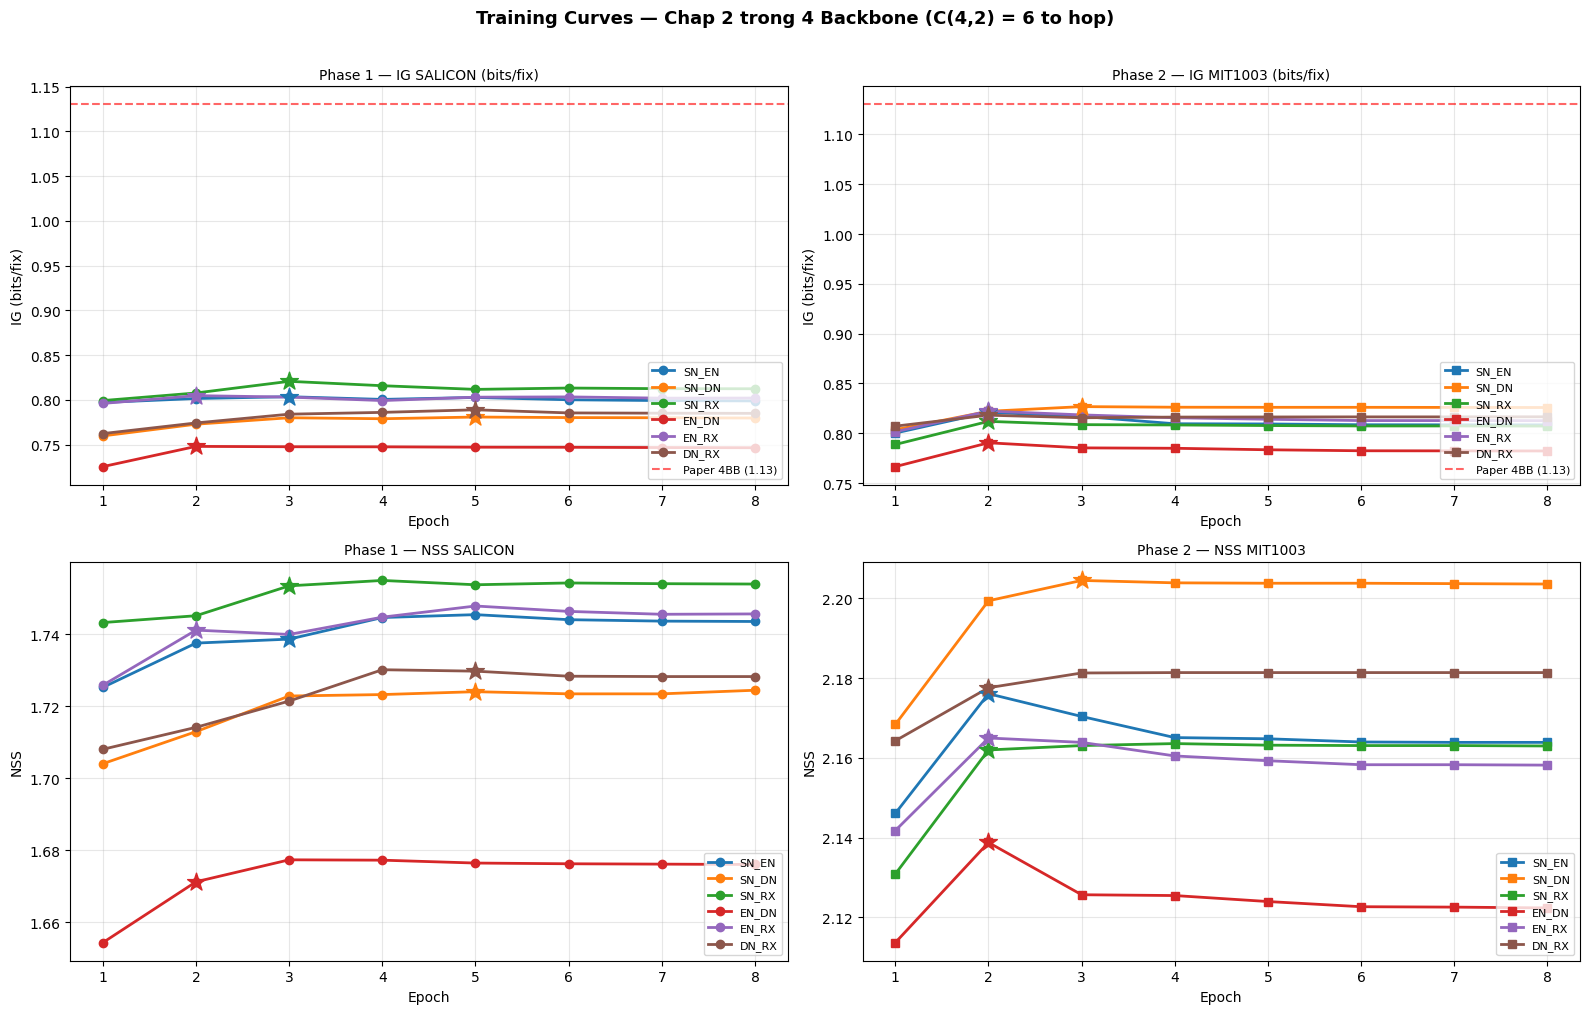

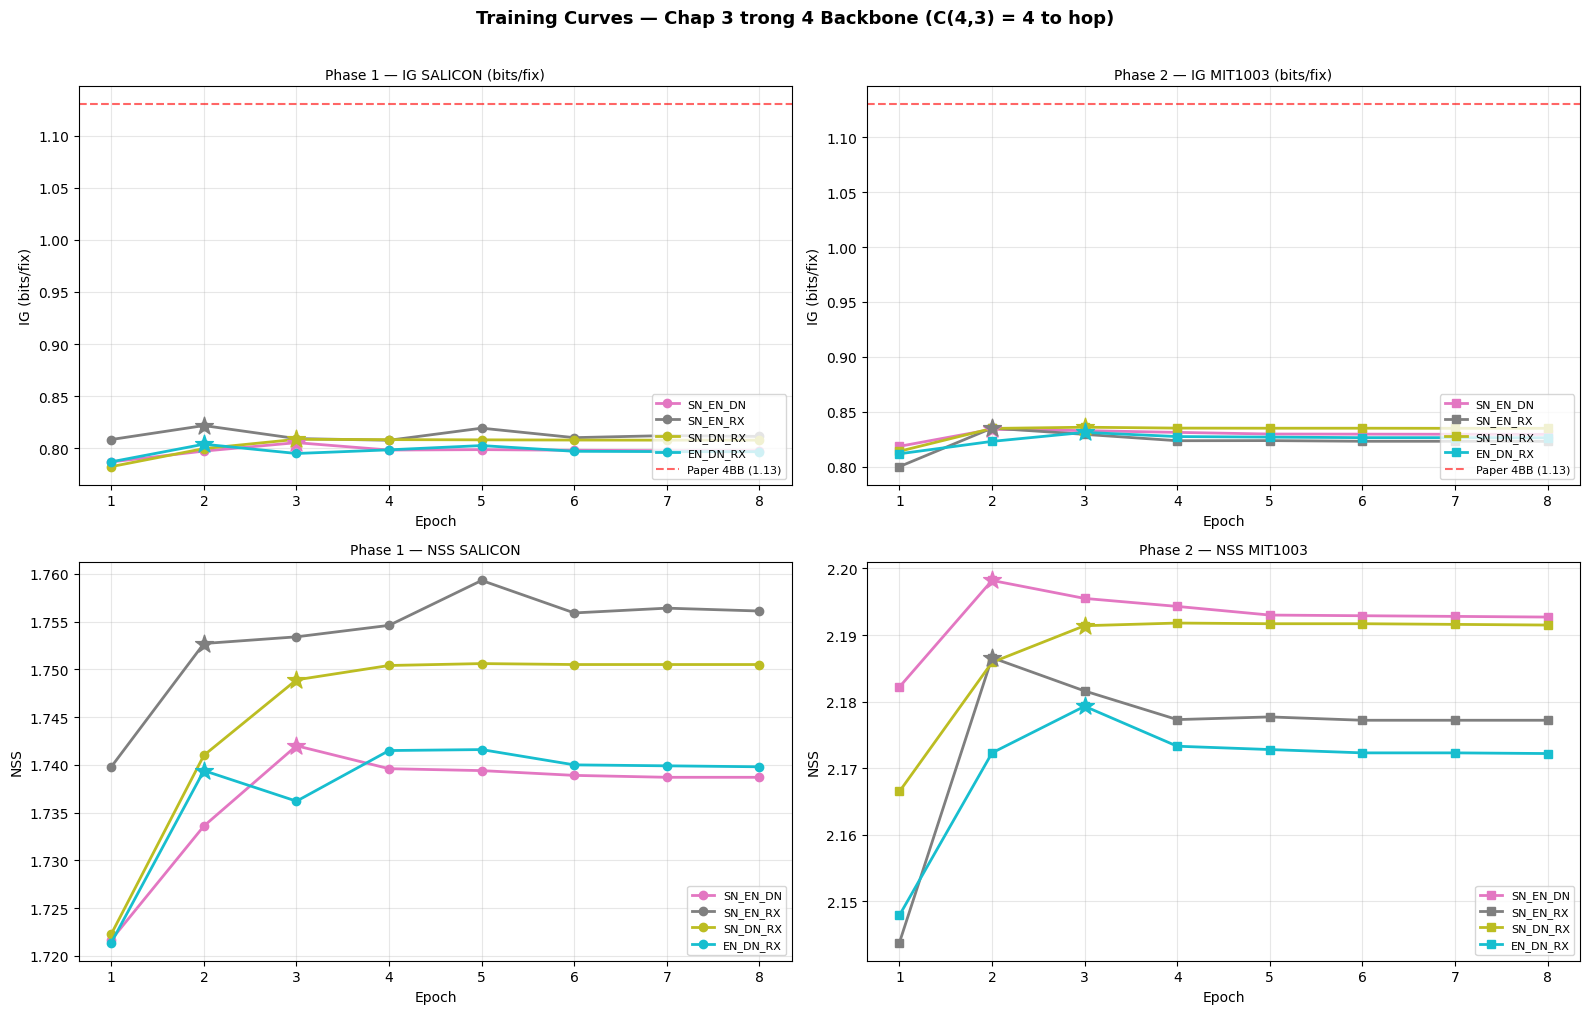

In [14]:
# ============================================================
# CELL 13: TRAINING CURVES
# Ve IG va NSS qua cac epoch cho tat ca experiments
# Chia thanh 2 bieu do: Chap 2 va Chap 3
# ============================================================

COLORS_2BB = ['#1f77b4','#ff7f0e','#2ca02c','#d62728','#9467bd','#8c564b']
COLORS_3BB = ['#e377c2','#7f7f7f','#bcbd22','#17becf']

def plot_group(group_experiments, colors, group_title):
    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    fig.suptitle(group_title, fontsize=13, fontweight='bold', y=1.01)
    ax_ig_s, ax_ig_m   = axes[0]
    ax_nss_s, ax_nss_m = axes[1]

    has_any = False
    for exp_name, color in zip(group_experiments, colors):
        if exp_name not in ALL_DATA: continue
        d = ALL_DATA[exp_name]
        label = exp_name

        # Phase 1 — SALICON
        if d['sal_epochs']:
            has_any = True
            ep  = [r['epoch']   for r in d['sal_epochs']]
            ig  = [r['IG_bits'] for r in d['sal_epochs']]
            nss = [r['NSS']     for r in d['sal_epochs']]
            ax_ig_s.plot(ep,  ig,  'o-', color=color, lw=2, ms=6, label=label)
            ax_nss_s.plot(ep, nss, 'o-', color=color, lw=2, ms=6, label=label)
            if d['best_sal']:
                bep = d['best_sal']['epoch']
                ax_ig_s.scatter(bep, d['best_sal']['IG_bits'], s=180, color=color, marker='*', zorder=5)
                ax_nss_s.scatter(bep, d['best_sal']['NSS'],    s=180, color=color, marker='*', zorder=5)

        # Phase 2 — MIT1003
        if d['mit_epochs']:
            ep  = [r['epoch']   for r in d['mit_epochs']]
            ig  = [r['IG_bits'] for r in d['mit_epochs']]
            nss = [r['NSS']     for r in d['mit_epochs']]
            ax_ig_m.plot(ep,  ig,  's-', color=color, lw=2, ms=6, label=label)
            ax_nss_m.plot(ep, nss, 's-', color=color, lw=2, ms=6, label=label)
            if d['best_mit']:
                bep = d['best_mit']['epoch']
                ax_ig_m.scatter(bep, d['best_mit']['IG_bits'], s=180, color=color, marker='*', zorder=5)
                ax_nss_m.scatter(bep, d['best_mit']['NSS'],    s=180, color=color, marker='*', zorder=5)

    # Duong tham chieu paper
    for ax in [ax_ig_s, ax_ig_m]:
        ax.axhline(1.13, color='red', ls='--', lw=1.5, alpha=0.6, label='Paper 4BB (1.13)')

    titles = ['Phase 1 — IG SALICON (bits/fix)',
              'Phase 2 — IG MIT1003 (bits/fix)',
              'Phase 1 — NSS SALICON',
              'Phase 2 — NSS MIT1003']
    ylabels= ['IG (bits/fix)','IG (bits/fix)','NSS','NSS']
    for ax, t, yl in zip(axes.flat, titles, ylabels):
        ax.set_title(t, fontsize=10)
        ax.set_xlabel('Epoch')
        ax.set_ylabel(yl)
        ax.legend(fontsize=8, loc='lower right')
        ax.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()
    if not has_any:
        print(f'  (Chua co du lieu cho nhom nay)')

# Nhom chap 2
plot_group(
    ['SN_EN','SN_DN','SN_RX','EN_DN','EN_RX','DN_RX'],
    COLORS_2BB,
    'Training Curves — Chap 2 trong 4 Backbone (C(4,2) = 6 to hop)'
)

# Nhom chap 3
plot_group(
    ['SN_EN_DN','SN_EN_RX','SN_DN_RX','EN_DN_RX'],
    COLORS_3BB,
    'Training Curves — Chap 3 trong 4 Backbone (C(4,3) = 4 to hop)'
)


---
## Cell 14 — Biểu đồ so sánh Best IG và NSS

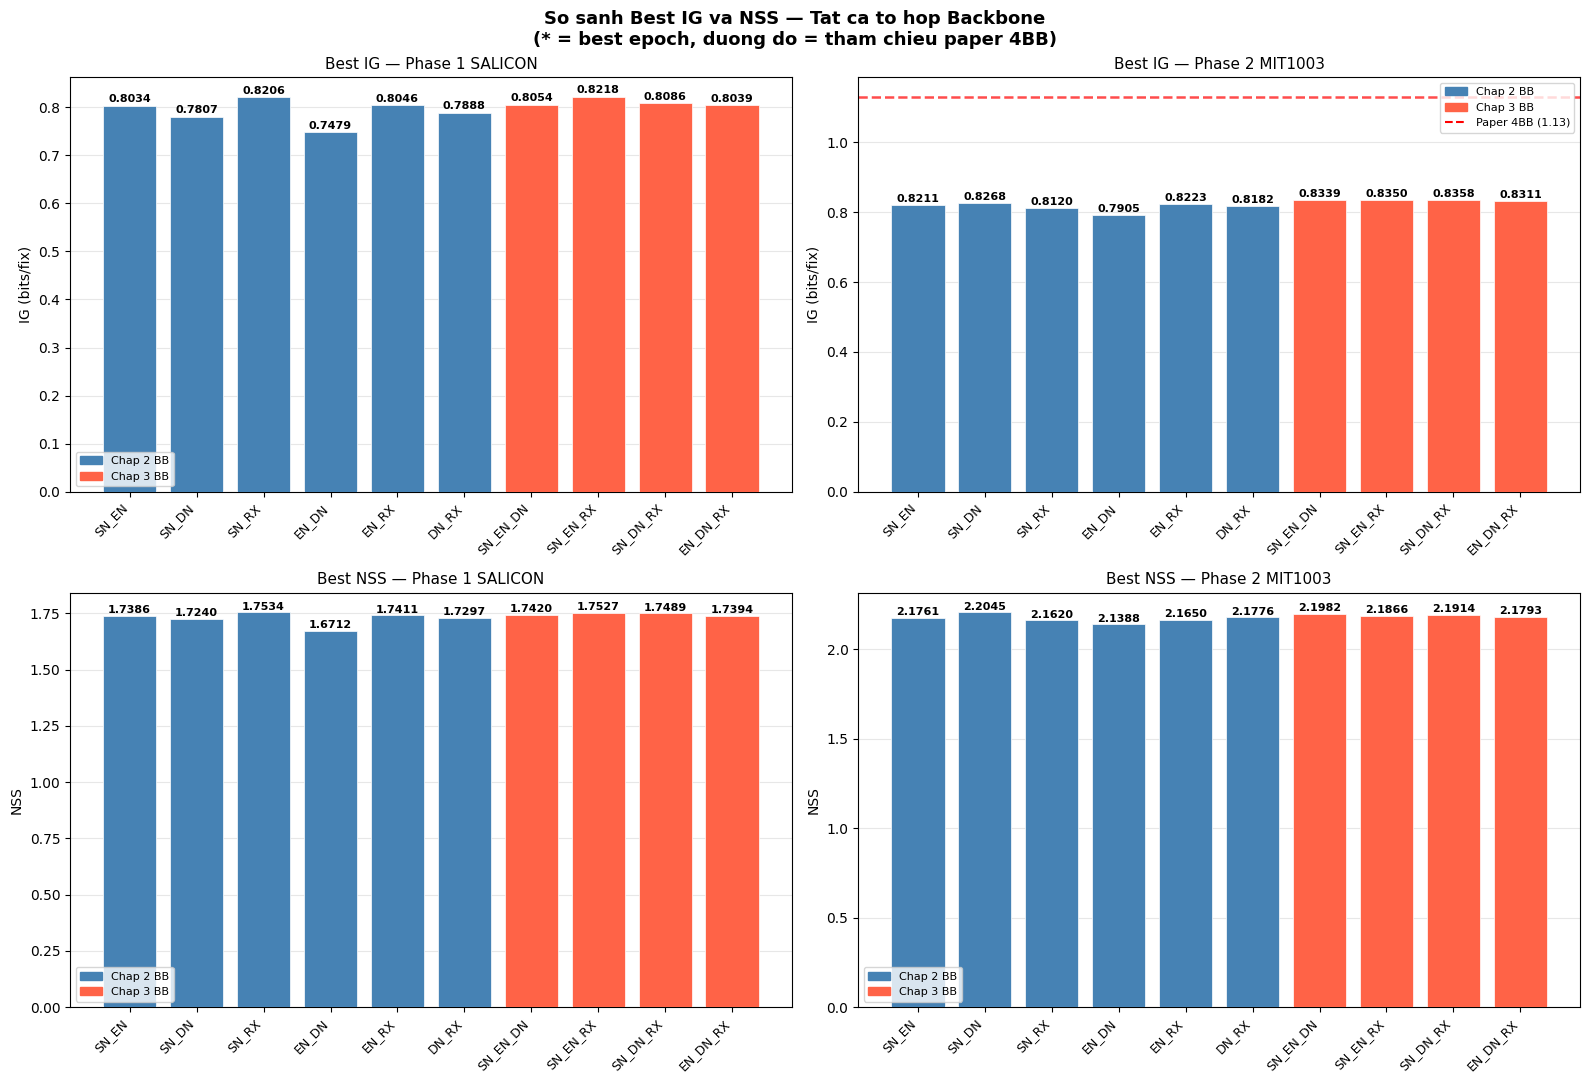


RANKING THEO IG MIT1003 (bits/fix):
------------------------------------------------------------
  # 1 SN_DN_RX     | IG=0.8358 bits | NSS=2.1914 | 3BB
  # 2 SN_EN_RX     | IG=0.8350 bits | NSS=2.1866 | 3BB
  # 3 SN_EN_DN     | IG=0.8339 bits | NSS=2.1982 | 3BB
  # 4 EN_DN_RX     | IG=0.8311 bits | NSS=2.1793 | 3BB
  # 5 SN_DN        | IG=0.8268 bits | NSS=2.2045 | 2BB
  # 6 EN_RX        | IG=0.8223 bits | NSS=2.1650 | 2BB
  # 7 SN_EN        | IG=0.8211 bits | NSS=2.1761 | 2BB
  # 8 DN_RX        | IG=0.8182 bits | NSS=2.1776 | 2BB
  # 9 SN_RX        | IG=0.8120 bits | NSS=2.1620 | 2BB
  #10 EN_DN        | IG=0.7905 bits | NSS=2.1388 | 2BB

  REF: Paper 4BB = 1.13 bits/fix
  REF: DeepGaze II = 0.93 bits/fix


In [15]:
# ============================================================
# CELL 14: BAR CHART SO SANH BEST IG VA NSS
# ============================================================

# Thu thap du lieu
exp_list, ig_sal_list, ig_mit_list = [], [], []
nss_sal_list, nss_mit_list, grp_list = [], [], []

for exp_name in ALL_EXPERIMENTS_INFO:
    if exp_name not in ALL_DATA: continue
    d = ALL_DATA[exp_name]
    exp_list.append(exp_name)
    ig_sal_list.append(d['best_sal'].get('IG_bits',  np.nan) if d['best_sal'] else np.nan)
    ig_mit_list.append(d['best_mit'].get('IG_bits',  np.nan) if d['best_mit'] else np.nan)
    nss_sal_list.append(d['best_sal'].get('NSS',     np.nan) if d['best_sal'] else np.nan)
    nss_mit_list.append(d['best_mit'].get('NSS',     np.nan) if d['best_mit'] else np.nan)
    grp_list.append(d['n_bb'])

if not exp_list:
    print('Chua co du lieu. Chay Cell 2-11 truoc.')
else:
    x    = np.arange(len(exp_list))
    clrs = ['steelblue' if g==2 else 'tomato' for g in grp_list]

    fig, axes = plt.subplots(2, 2, figsize=(16, 11))
    fig.suptitle('So sanh Best IG va NSS — Tat ca to hop Backbone\n'
                 '(* = best epoch, duong do = tham chieu paper 4BB)',
                 fontsize=13, fontweight='bold')

    def bar_plot(ax, vals, title, ylabel, ref_line=None):
        bars = ax.bar(x, vals, color=clrs, edgecolor='white', lw=0.5, zorder=3)
        if ref_line:
            ax.axhline(ref_line, color='red', ls='--', lw=1.8,
                       alpha=0.7, label=f'Paper 4BB: {ref_line}')
        for bar, val in zip(bars, vals):
            if not np.isnan(val):
                ax.text(bar.get_x()+bar.get_width()/2,
                        bar.get_height()+0.003,
                        f'{val:.4f}', ha='center', va='bottom',
                        fontsize=8, fontweight='bold')
        ax.set_xticks(x)
        ax.set_xticklabels(exp_list, rotation=45, ha='right', fontsize=9)
        ax.set_ylabel(ylabel)
        ax.set_title(title, fontsize=11)
        ax.grid(axis='y', alpha=0.3, zorder=0)
        handles = [
            mpatches.Patch(color='steelblue', label='Chap 2 BB'),
            mpatches.Patch(color='tomato',    label='Chap 3 BB'),
        ]
        if ref_line:
            handles.append(plt.Line2D([0],[0],color='red',ls='--',
                                       label=f'Paper 4BB ({ref_line})'))
        ax.legend(handles=handles, fontsize=8)

    bar_plot(axes[0,0], ig_sal_list,  'Best IG — Phase 1 SALICON', 'IG (bits/fix)', ref_line=None)
    bar_plot(axes[0,1], ig_mit_list,  'Best IG — Phase 2 MIT1003', 'IG (bits/fix)', ref_line=1.13)
    bar_plot(axes[1,0], nss_sal_list, 'Best NSS — Phase 1 SALICON', 'NSS', ref_line=None)
    bar_plot(axes[1,1], nss_mit_list, 'Best NSS — Phase 2 MIT1003', 'NSS', ref_line=None)

    plt.tight_layout()
    plt.show()

    # Ranking
    print('\nRANKING THEO IG MIT1003 (bits/fix):')
    print('-'*60)
    ranked = sorted(zip(exp_list, ig_mit_list, nss_mit_list, grp_list),
                    key=lambda r: r[1] if not np.isnan(r[1]) else -999,
                    reverse=True)
    for rank, (name, ig, nss_v, n) in enumerate(ranked, 1):
        ig_str  = f'{ig:.4f}'   if not np.isnan(ig)    else 'N/A '
        nss_str = f'{nss_v:.4f}' if not np.isnan(nss_v) else 'N/A '
        print(f'  #{rank:2d} {name:12s} | IG={ig_str} bits | NSS={nss_str} | {n}BB')
    print(f'\n  REF: Paper 4BB = 1.13 bits/fix')
    print(f'  REF: DeepGaze II = 0.93 bits/fix')
